CNN + Metric Learning for TAU 2019 Acoustic Scenes

- Log-mel CNN dataset creation with **waveform data augmentation**
- CNN training with early stopping
- Saving the best model weights to cnn_best.pt
- Evaluation on the test set with confusion matrix and saliency visualization
- **Research extension: Metric learning** via using CNN embeddings with k-NN in embedding space and comparing performance.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tqdm.auto import tqdm

sns.set(style='whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

SR = 22050
RANDOM_STATE = 42
CNN_CONFIG = {
    'n_mels': 64,
    'hop_length': 320,
    'fmin': 50,
    'fmax': None,
    'max_frames': 256,
    'n_aug': 1,
    'batch_size': 32,
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'epochs': 20,
}

def read_meta(path: str = 'meta.csv') :
    if not os.path.exists(path):
        raise FileNotFoundError('meta.csv not found')
    meta = pd.read_csv(path, sep='\t', quotechar='"')
    required = ['filename', 'scene_label', 'identifier']
    for c in required:
        if c not in meta:
            raise ValueError(f'Missing {c} in meta')
    meta['filepath'] = meta['filename'].apply(lambda f: os.path.join('.', f))
    return meta


Using device: cpu


c:\Users\haizi\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# waveform augmentations
import numpy.random as npr

def aug_time_shift(y: np.ndarray, max_frac: float = 0.1):
    max_shift = int(len(y) * max_frac)
    shift = npr.randint(-max_shift, max_shift + 1)
    return np.roll(y, shift)

def aug_gain(y: np.ndarray, min_db: float = -6.0, max_db: float = 6.0):
    gain_db = npr.uniform(min_db, max_db)
    gain = 10.0 ** (gain_db / 20.0)
    return y * gain

def aug_add_noise(y: np.ndarray, snr_db: float = 20.0):
    sig_power = np.mean(y ** 2) + 1e-8
    snr = 10.0 ** (snr_db / 10.0)
    noise_power = sig_power / snr
    noise = np.sqrt(noise_power) * npr.randn(len(y))
    return y + noise

AUG_FUNCS = [aug_time_shift, aug_gain, aug_add_noise]

def make_aug_variants(y: np.ndarray, n_aug: int, sr: int = SR):
    outs = [y.astype(np.float32)]
    if n_aug <= 0:
        return outs
    for _ in range(n_aug):
        z = y.astype(np.float32)
        k = npr.randint(1, len(AUG_FUNCS) + 1)
        for f in npr.choice(AUG_FUNCS, size=k, replace=False):
            z = f(z)
        outs.append(z.astype(np.float32))
    return outs


In [3]:
# logmel CNN
class LogMelCNNDataset(Dataset):
    def __init__(
        self,
        meta: pd.DataFrame,
        indices,
        label_encoder: LabelEncoder,
        n_mels: int,
        hop: int,
        fmin: int,
        fmax,
        max_frames: int,
        train: bool,
        n_aug: int,
    ):
        self.meta = meta.reset_index(drop=True)
        self.indices = np.array(indices, dtype=int)
        self.le = label_encoder
        self.n_mels = n_mels
        self.hop = hop
        self.fmin = fmin
        self.fmax = fmax if fmax is not None else SR // 2
        self.max_frames = max_frames
        self.train = train
        self.n_aug = n_aug

    def __len__(self):
        return len(self.indices)

    def _wav_to_logmel(self, y: np.ndarray):
        S = librosa.feature.melspectrogram(
            y=y,
            sr=SR,
            n_mels=self.n_mels,
            hop_length=self.hop,
            fmin=self.fmin,
            fmax=self.fmax,
            power=2.0,
        )
        L = librosa.power_to_db(S, ref=np.max).astype(np.float32)
        mu = float(L.mean())
        sd = float(L.std() + 1e-8)
        L = (L - mu) / sd
        return L

    def _pad_or_crop(self, S: np.ndarray):
        T = S.shape[1]
        if T < self.max_frames:
            pad_width = self.max_frames - T
            S = np.pad(S, ((0, 0), (0, pad_width)), mode='constant')
        else:
            S = S[:, : self.max_frames]
        return S

    def __getitem__(self, idx):
        idx = self.indices[idx]
        row = self.meta.iloc[idx]
        path = row['filepath']
        y, _ = librosa.load(path, sr=SR, mono=True)
        if self.train and self.n_aug > 0:
            variants = make_aug_variants(y, n_aug=self.n_aug, sr=SR)
            choice = np.random.randint(0, len(variants))
            y = variants[choice].astype(np.float32)
        S = self._wav_to_logmel(y)
        S = self._pad_or_crop(S)
        x = torch.from_numpy(S).float().unsqueeze(0)
        label_str = row['scene_label']
        y_idx = self.le.transform([label_str])[0]
        y_t = torch.tensor(y_idx, dtype=torch.long)
        return x, y_t


In [4]:
# model def
class CRNN(nn.Module):
    def __init__(self, n_classes: int, n_mels: int, n_frames: int):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
        )
        self.freq_bins = n_mels // 8
        self.lstm_input_size = 128 * self.freq_bins
        self.lstm_hidden = 128
        self.lstm = nn.LSTM(
            input_size=self.lstm_input_size,
            hidden_size=self.lstm_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.fc = nn.Linear(self.lstm_hidden * 2, n_classes)

    def forward(self, x):
        z = self.cnn(x)
        B, C, F, T = z.shape
        z = z.permute(0, 3, 1, 2).contiguous().view(B, T, C * F)
        out, _ = self.lstm(z)
        out = out[:, -1, :]
        logits = self.fc(out)
        return logits

class CRNNWithEmbedding(nn.Module):
    def __init__(self, base_model: CRNN):
        super().__init__()
        self.cnn = base_model.cnn
        self.lstm = base_model.lstm
        self.fc = base_model.fc

    def forward(self, x, return_embedding: bool = False):
        z = self.cnn(x)
        B, C, F, T = z.shape
        z = z.permute(0, 3, 1, 2).contiguous().view(B, T, C * F)
        out, _ = self.lstm(z)
        emb = out[:, -1, :]
        logits = self.fc(emb)
        if return_embedding:
            return emb, logits
        return logits


In [5]:
# load split
meta = read_meta('meta.csv')
splits = np.load('splits_tau2019_grouped.npz')
tr_idx, va_idx, te_idx = splits['tr_idx'], splits['va_idx'], splits['te_idx']

le = LabelEncoder()
le.fit(meta['scene_label'])
n_classes = len(le.classes_)
print('Classes:', n_classes, list(le.classes_))

n_mels = CNN_CONFIG['n_mels']
hop = CNN_CONFIG['hop_length']
fmin = CNN_CONFIG['fmin']
fmax = CNN_CONFIG['fmax']
max_frames = CNN_CONFIG['max_frames']
n_aug = CNN_CONFIG['n_aug']

train_ds = LogMelCNNDataset(meta, tr_idx, le, n_mels, hop, fmin, fmax, max_frames, train=True, n_aug=n_aug)
val_ds   = LogMelCNNDataset(meta, va_idx, le, n_mels, hop, fmin, fmax, max_frames, train=False, n_aug=0)
test_ds  = LogMelCNNDataset(meta, te_idx, le, n_mels, hop, fmin, fmax, max_frames, train=False, n_aug=0)

# Use single-process data loading to avoid hanging
train_loader = DataLoader(
    train_ds,
    batch_size=CNN_CONFIG['batch_size'],
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=CNN_CONFIG['batch_size'],
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=CNN_CONFIG['batch_size'],
    shuffle=False,
    num_workers=0, 
    pin_memory=False
)


len(train_ds), len(val_ds), len(test_ds)


Classes: 10 ['airport', 'bus', 'metro', 'metro_station', 'park', 'public_square', 'shopping_mall', 'street_pedestrian', 'street_traffic', 'tram']


(9309, 2347, 2744)

In [6]:
# Create model and optimizer
model = CRNN(n_classes=n_classes, n_mels=n_mels, n_frames=max_frames).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CNN_CONFIG['lr'],
    weight_decay=CNN_CONFIG['weight_decay'],
)


In [7]:
# Training and evaluation loops
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in tqdm(loader, desc='Train', leave=False):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * yb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device, split_name='Val'):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in tqdm(loader, desc=split_name, leave=False):
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            running_loss += loss.item() * yb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(yb.cpu().numpy())
    if total == 0:
        return 0.0, 0.0, None, None
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    return running_loss / total, correct / total, all_preds, all_targets


In [8]:
# train eval
n_epochs = CNN_CONFIG['epochs']
best_val_acc = 0.0
best_state = None
if os.path.exists('cnn_best.pt'):
    print("cnn_best.pt already exists. Skip training.")
    model.load_state_dict(torch.load('cnn_best.pt', map_location=device))
    model.to(device)
else:
    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc, _, _ = evaluate(model, val_loader, criterion, device, split_name='Val')
        print(f'Epoch {epoch:02d} | train loss {tr_loss:.4f}, acc {tr_acc:.4f} | '
            f'val loss {va_loss:.4f}, acc {va_acc:.4f}')
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = model.state_dict().copy()

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), 'cnn_best.pt')
        print('Saved best CNN weights to cnn_best.pt')


cnn_best.pt already exists. Skip training.


C:\Users\haizi\AppData\Local\Temp\ipykernel_19004\1083143861.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('cnn_best.pt', map_location

In [9]:
# eval on test
test_loss, test_acc, y_pred_cnn, y_true_cnn = evaluate(model, test_loader, criterion, device, split_name='Test')
print(f'Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}')
print(classification_report(y_true_cnn, y_pred_cnn, target_names=le.classes_))


Test loss: 1.5282, Test acc: 0.4825
                   precision    recall  f1-score   support

          airport       0.58      0.16      0.25       192
              bus       0.57      0.42      0.49       341
            metro       0.39      0.50      0.43       333
    metro_station       0.33      0.66      0.44       307
             park       0.86      0.63      0.72       403
    public_square       0.41      0.14      0.21       211
    shopping_mall       0.42      0.76      0.54       229
street_pedestrian       0.51      0.27      0.35       282
   street_traffic       0.51      0.78      0.62        97
             tram       0.57      0.50      0.53       349

         accuracy                           0.48      2744
        macro avg       0.51      0.48      0.46      2744
     weighted avg       0.53      0.48      0.47      2744



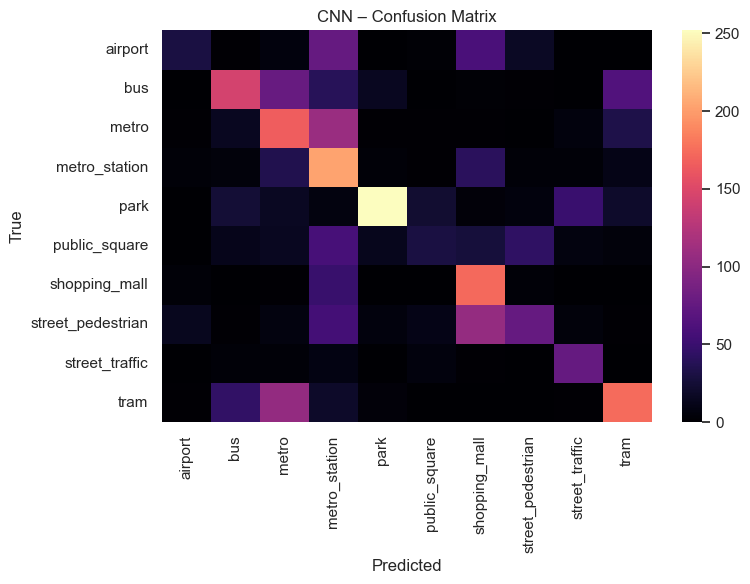

In [10]:
# confusion matrix
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=False, cmap='magma',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CNN – Confusion Matrix')
plt.tight_layout()
plt.show()


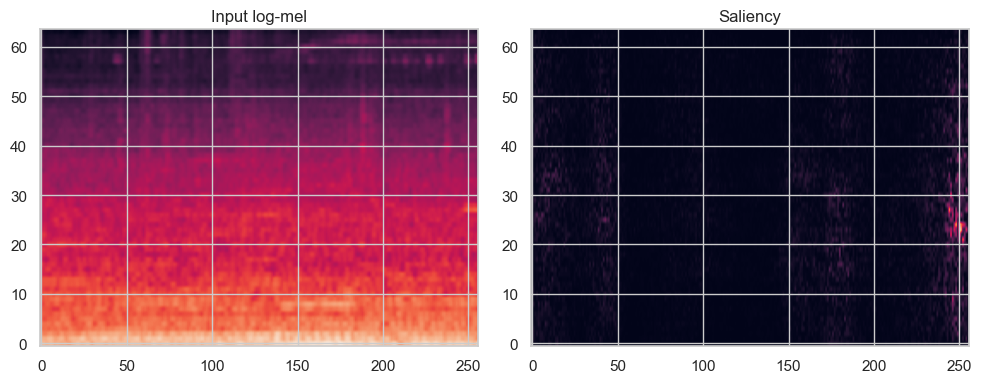

In [11]:
# interpretation
def compute_saliency(model, x, target_class=None):
    model.eval()
    x = x.to(device).requires_grad_(True)
    logits = model(x)
    if target_class is None:
        target_class = logits.argmax(dim=1)
    loss = logits[0, target_class]
    loss.backward()
    sal = x.grad.detach().abs().cpu().numpy()[0, 0]
    return sal

# sample test
x_example, y_example = test_ds[0]
x_example = x_example.unsqueeze(0)
saliency = compute_saliency(model, x_example, target_class=y_example)
spect = x_example[0, 0].detach().numpy()
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(spect, aspect='auto', origin='lower')
plt.title('Input log-mel')
plt.subplot(1, 2, 2)
plt.imshow(saliency, aspect='auto', origin='lower')
plt.title('Saliency')
plt.tight_layout()
plt.show()


In [12]:
# metric learning extension
embed_model = CRNNWithEmbedding(model).to(device)
embed_model.eval()

def get_embeddings(dset, model, batch_size=64):
    loader = DataLoader(dset, batch_size=batch_size, shuffle=False)
    embs, labels = [], []
    with torch.no_grad():
        for xb, yb in tqdm(loader, desc='Embeddings', leave=False):
            xb = xb.to(device)
            emb, _ = model(xb, return_embedding=True)
            embs.append(emb.cpu().numpy())
            labels.append(yb.numpy())
    return np.vstack(embs), np.concatenate(labels)

train_val_ds = ConcatDataset([train_ds, val_ds])
emb_tr, lab_tr = get_embeddings(train_val_ds, embed_model)
emb_te, lab_te = get_embeddings(test_ds, embed_model)
print('Embedding shapes:', emb_tr.shape, emb_te.shape)


Embedding shapes: (11656, 256) (2744, 256)


In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5, metric='cosine')
knn.fit(emb_tr, lab_tr)
y_pred_knn = knn.predict(emb_te)
knn_acc = accuracy_score(lab_te, y_pred_knn)
print('CNN softmax acc (test):', test_acc)
print('k-NN on embeddings acc (test):', knn_acc)
print(classification_report(lab_te, y_pred_knn, target_names=le.classes_))


CNN softmax acc (test): 0.48250728862973763
k-NN on embeddings acc (test): 0.5112973760932945
                   precision    recall  f1-score   support

          airport       0.36      0.60      0.45       192
              bus       0.47      0.60      0.52       341
            metro       0.52      0.45      0.48       333
    metro_station       0.44      0.40      0.42       307
             park       0.84      0.73      0.78       403
    public_square       0.34      0.27      0.30       211
    shopping_mall       0.44      0.58      0.50       229
street_pedestrian       0.49      0.29      0.36       282
   street_traffic       0.55      0.76      0.64        97
             tram       0.56      0.49      0.52       349

         accuracy                           0.51      2744
        macro avg       0.50      0.52      0.50      2744
     weighted avg       0.52      0.51      0.51      2744

